# Single Lead Data Prep:

This notebook does the following:
1) Configs
  - 1.1) Main Data Paths
  - 1.2) Python File Imports
  - 1.3) Config Values
2) Dataset Overview
  - 2.1) dump_duke data (ID)
  - 2.2) raw_data_add_v1 (ID)
  - 2.3) ECG_OOD (OOD)
3) Helper Functions
  - 3.1) File Loading
  - 3.2) ECG Extraction
  - 3.3) Signal Cleaning
  - 3.4) Windowing
  - 3.5) R-Peak Detection
  - 3.6) Metadata
4) Load Raw ID Data
  - 4.1) Load dump_duke
  - 4.2) Load raw_data_add_v1
  - 4.3) Merge ID data
5) Load Raw OOD Data
  - 5.1) Load ECG_OOD
  - 5.2) Merge OOD data
6) Sanity Checks
  - 6.1) Visualizations
7) Signal Cleaning + Standardization
  7.1) Extract Single Lead
  7.2) Apply Filters
  7.3) Handle Invalid/Too-Short signals
  7.4) Standardize Output Shape
8) Record-Level Train/Validation/Test Splits
  - 8.1) ID Splits
  - 8.2) OOD Test Set
  - 8.3) Save Split
9) Windowing
  - 9.1) Windowing
10) Normalization
  - 10.1) Apply to Splits
11) Save Data
  - 11.1) Save Arrays
  - 11.2) Save Metadata
  - 11.3) Save Split JSON
12) Visualizations


# 0) Imports

In [1]:
!pip install heartpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.9 MB/s eta 0:00:00


In [2]:
import os
import glob
import json
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import heartpy

from pathlib import Path
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1) Configs

### 1.1) Main Data Paths

In [4]:
#Main Paths
PROJECT_ROOT = Path("/content/drive/My Drive/Duke/Semester 4")

DATA_DIR = PROJECT_ROOT / "data"
SRC_DIR = PROJECT_ROOT / "singlelead_ecgad" / "src"

sys.path.append(str(SRC_DIR))

In [5]:
#Raw Data Paths
ID_DUMP_DUKE_DIR = DATA_DIR / "dump_duke"
ID_RAW_DATA_DIR = DATA_DIR / "raw_data_add_v1"

OOD_DATA_DIR = DATA_DIR / "ECG_OOD" / "data" / "ecg_invalid_0603" / "raw"

PREPARED_DATA_DIR = PROJECT_ROOT / "singlelead_ecgad" / "data_singlelead"
CLEANED_DATA_DIR = PREPARED_DATA_DIR / "cleaned_data"
WINDOWED_DATA_DIR = PREPARED_DATA_DIR / "windowed"
META_DATA_DIR = PREPARED_DATA_DIR / "metadata"

PREPARED_DATA_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_DATA_DIR.mkdir(parents=True, exist_ok=True)
WINDOWED_DATA_DIR.mkdir(parents=True, exist_ok=True)
META_DATA_DIR.mkdir(parents=True, exist_ok=True)

### 1.2) Python File Imports

In [6]:
#Data Loading
from data_processors.dataloaders import (
    list_json_files,
    list_csv_files,
    load_json_file,
    load_csv_file,
    get_file_stem,
    get_parent_folder_name,
    infer_source_name,
    infer_record_id,
    summarize_file_inventory
)

In [7]:
#ECG Extraction
from data_processors.ecg_extraction import (
    extract_ecg_from_dump_duke,
    extract_ecg_from_csv,
    extract_pcg_from_csv,
    ensure_1d_signal,
    extract_category_from_dump_duke,
    build_record_dict_from_dump_duke,
    build_record_dict_from_csv
)

In [8]:
#Signal Cleaning
from data_processors.signal_cleaning import (
    nan_ratio,
    fill_nans,
    butter_bandpass_filter,
    notch_filter,
    zscore_normalize,
    minmax_normalize,
    normalize_signal,
    is_valid_signal,
    clean_ecg_signal
)

In [9]:
#Windowing
from data_processors.windowing import (
    compute_stride,
    generate_window_ranges,
    extract_windows,
    window_record
)

In [10]:
#R-peak detection
from data_processors.rpeak import (
    detect_rpeaks_heartpy,
    filter_rpeaks_near_edges,
    extract_beat_segments,
    detect_and_extract_beats
)

In [11]:
#Metadata utils
from data_processors.metadata_loader import (
    build_record_metadata,
    build_window_metadata,
    records_to_metadata_df,
    windows_to_metadata_df
)

In [12]:
def save_metadata(df, name):
    """
    Save metadata DataFrame immediately after creation.
    """
    path = META_DATA_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved metadata: {path}  ({len(df)} rows)")

### 1.3) Config Values

In [13]:
#Experiment settings
SAMPLING_RATE = 1000 #Hz

WINDOW_SIZES = [2500, 5000, 10000]

WINDOW_STRIDE_RATIO = 0.5

In [14]:
#Signal Filtering Settings
#Butterworth bandpass filter (standard)
LOWCUT = 0.5 #Hz
HIGHCUT = 40 #Hz
FILTER_ORDER = 4

#Notch Filter
NOTCH_FREQ = 60
QUALITY_FACTOR = 30

In [15]:
#Data Split Settings
#Train/validation/test (ID-ONLY)
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

RANDOM_SEED = 42

In [16]:
#Misc quality control
#Minimum signal length for window
MIN_SIGNAL_LENGTH = 10000

#Drop windows with too many NaNs
MAX_NAN_RATIO = 0.1

In [17]:
#R-Peak Detection settings
ENABLE_RPEAK_DETECTION = True

#Heartbeat snippet lengths (for ECGAD local branch)
RPEAK_PRE_SAMPLES = int(0.2 * SAMPLING_RATE)   # 200 ms
RPEAK_POST_SAMPLES = int(0.4 * SAMPLING_RATE)  # 400 ms

In [18]:
#Normalization Strategy
NORMALIZATION_METHOD = 'zscore'

EPSILON = 1e-8

In [19]:
#Ssave format
SAVE_FORMAT = 'numpy'

SAVE_METADATA = True
SAVE_RPEAKS = True

In [20]:
print("Configuration Summary")
print("---------------------")
print("Sampling rate:", SAMPLING_RATE)
print("Window sizes:", WINDOW_SIZES)
print("Train/Val/Test:", TRAIN_RATIO, VAL_RATIO, TEST_RATIO)
print("Normalization:", NORMALIZATION_METHOD)
print("R-peak detection:", ENABLE_RPEAK_DETECTION)

Configuration Summary
---------------------
Sampling rate: 1000
Window sizes: [2500, 5000, 10000]
Train/Val/Test: 0.7 0.15 0.15
Normalization: zscore
R-peak detection: True


## 2) Dataset Overview

In [21]:
print("dump_duke files:", len(list(ID_DUMP_DUKE_DIR.glob("*"))))
print("raw_data_add_v1 files:", len(list(ID_RAW_DATA_DIR.glob("*"))))
print("ECG_OOD files:", len(list(OOD_DATA_DIR.glob("*"))))

dump_duke files: 6
raw_data_add_v1 files: 5519
ECG_OOD files: 2884


### 2.1) dump_duke (ID)

In [22]:
dump_duke_categories = [p for p in ID_DUMP_DUKE_DIR.iterdir() if p.is_dir()]

counts = {}

for category in dump_duke_categories:
    counts[category.name] = len(list(category.glob("*.json")))

pd.Series(counts).sort_index()

,0
AF,519
AF_PAC,2
AF_PVC,15
NORMAL,194
PAC,222
PAC_PVC,18


In [23]:
example_file = list((ID_DUMP_DUKE_DIR / "NORMAL").glob("*.json"))[0]

with open(example_file) as f:
    data = json.load(f)

data.keys()

dict_keys(['record_id', 'category', 'comments', 'raw_data', 'manual_result'])

In [24]:
ecg = np.array(data["raw_data"]["ecg"])

print("Shape:", ecg.shape)
print("First few samples:", ecg[:10])

Shape: (59647,)
First few samples: [1773. 1773. 1768. 1768. 1760. 1760. 1753. 1753. 1747. 1747.]


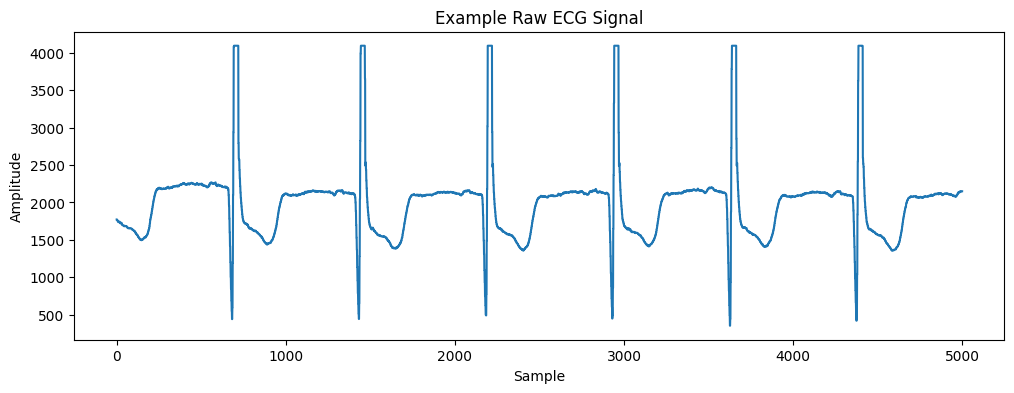

In [25]:
plt.figure(figsize=(12,4))
plt.plot(ecg[:5000])
plt.title("Example Raw ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

### 2.2) raw_data_add_v1 (ID)

In [26]:
raw_add_files = list(ID_RAW_DATA_DIR.glob("*.csv"))
print("Number of CSV files:", len(raw_add_files))
raw_add_files[:5]

Number of CSV files: 5519


[PosixPath('/content/drive/My Drive/Duke/Semester 4/data/raw_data_add_v1/rcda62b0f9020250911101418_p1.csv'),
 PosixPath('/content/drive/My Drive/Duke/Semester 4/data/raw_data_add_v1/rcda62b0f9020250911101614_p1.csv'),
 PosixPath('/content/drive/My Drive/Duke/Semester 4/data/raw_data_add_v1/rcda62b0f9020250911101700_p1.csv'),
 PosixPath('/content/drive/My Drive/Duke/Semester 4/data/raw_data_add_v1/rcda62b0f9020250911101741_p1.csv'),
 PosixPath('/content/drive/My Drive/Duke/Semester 4/data/raw_data_add_v1/rcda62b0f9020250911101821_p1.csv')]

In [27]:
example_file = raw_add_files[0]
df = pd.read_csv(example_file)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (29952, 2)
Columns: ['ECG', 'PCG']


,ECG,PCG
0,2322,-138
1,2374,-76
2,2426,-22
3,2484,-10
4,2543,41


In [28]:
ecg = df["ECG"].to_numpy()

print("ECG shape:", ecg.shape)
print("First 10 values:", ecg[:10])

ECG shape: (29952,)
First 10 values: [2322 2374 2426 2484 2543 2601 2660 2738 2816 2892]


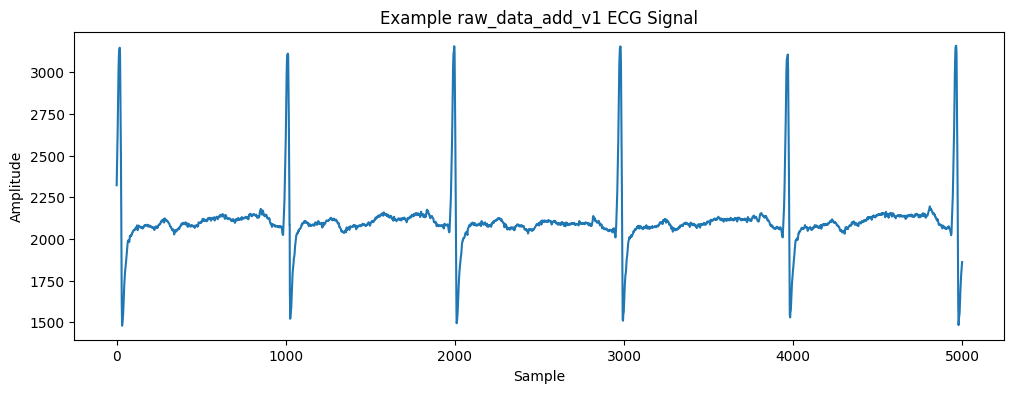

In [29]:
plt.figure(figsize=(12,4))
plt.plot(ecg[:5000])
plt.title("Example raw_data_add_v1 ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

### 2.3) ECG_OOD (OOD)

In [30]:
ood_files = list(OOD_DATA_DIR.glob("*.csv"))
print("Number of CSV files:", len(ood_files))
ood_files[:5]

Number of CSV files: 2884


[PosixPath('/content/drive/My Drive/Duke/Semester 4/data/ECG_OOD/data/ecg_invalid_0603/raw/rcd4ef8566720240513102158_p1.csv'),
 PosixPath('/content/drive/My Drive/Duke/Semester 4/data/ECG_OOD/data/ecg_invalid_0603/raw/rcd4ef8566720240513094408_p1.csv'),
 PosixPath('/content/drive/My Drive/Duke/Semester 4/data/ECG_OOD/data/ecg_invalid_0603/raw/rcdf612fd2320240517111206_p1.csv'),
 PosixPath('/content/drive/My Drive/Duke/Semester 4/data/ECG_OOD/data/ecg_invalid_0603/raw/rcdf612fd2320240517100433_p1.csv'),
 PosixPath('/content/drive/My Drive/Duke/Semester 4/data/ECG_OOD/data/ecg_invalid_0603/raw/rcd4ef8566720240513095454_p1.csv')]

In [31]:
example_file = ood_files[0]
df = pd.read_csv(example_file)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (32511, 2)
Columns: ['2313', '43']


,2313,43
0,2308,41
1,2303,39
2,2302,36
3,2301,34
4,2293,31


In [32]:
ecg = df["2313"].to_numpy()

print("ECG shape:", ecg.shape)
print("First 10 ECG values:", ecg[:10])

ECG shape: (32511,)
First 10 ECG values: [2308 2303 2302 2301 2293 2285 2280 2275 2289 2303]


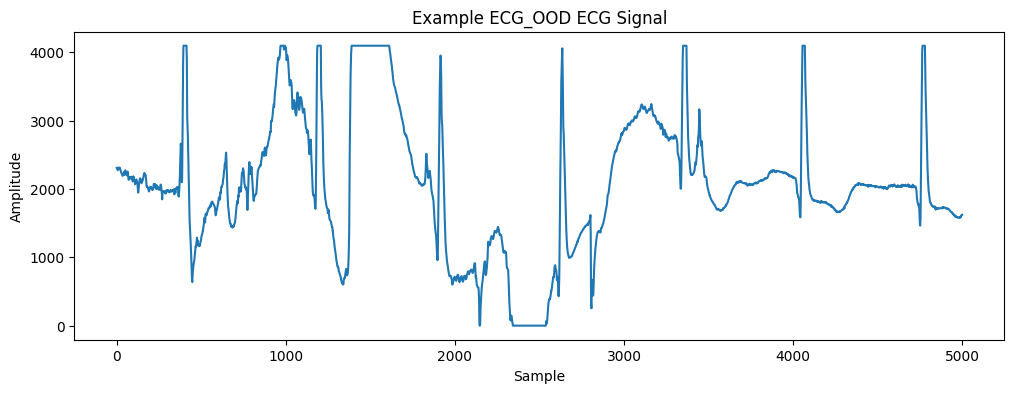

In [33]:
plt.figure(figsize=(12,4))
plt.plot(ecg[:5000])
plt.title("Example ECG_OOD ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

## 3) Helper Functions

### 3.1) File Loading

In [34]:
file_summary = summarize_file_inventory(
    ID_DUMP_DUKE_DIR,
    ID_RAW_DATA_DIR,
    OOD_DATA_DIR
)

file_summary

,0
dump_duke_json,970
raw_data_add_v1_csv,5519
ECG_OOD_csv,2884


### 3.2) ECG Extraction

In [35]:
# dump_duke example
dump_example_file = list_json_files(ID_DUMP_DUKE_DIR)[0]
dump_example_data = load_json_file(dump_example_file)
dump_record = build_record_dict_from_dump_duke(dump_example_file, dump_example_data)

print("dump_duke example:")
print("record_id:", dump_record["record_id"])
print("source:", dump_record["source"])
print("category:", dump_record["category"])
print("label:", dump_record["label"])
print("ecg shape:", dump_record["ecg"].shape)

# raw_data_add_v1 example
raw_example_file = list_csv_files(ID_RAW_DATA_DIR)[0]
raw_example_df = load_csv_file(raw_example_file)
raw_record = build_record_dict_from_csv(raw_example_file, raw_example_df, "raw_data_add_v1", "ID")

print("\nraw_data_add_v1 example:")
print("record_id:", raw_record["record_id"])
print("source:", raw_record["source"])
print("category:", raw_record["category"])
print("label:", raw_record["label"])
print("ecg shape:", raw_record["ecg"].shape)
print("pcg present:", raw_record["pcg"] is not None)

# ECG_OOD example
ood_example_file = list_csv_files(OOD_DATA_DIR)[0]
ood_example_df = load_csv_file(ood_example_file)
ood_record = build_record_dict_from_csv(ood_example_file, ood_example_df, "ECG_OOD", "OOD")

print("\nECG_OOD example:")
print("record_id:", ood_record["record_id"])
print("source:", ood_record["source"])
print("category:", ood_record["category"])
print("label:", ood_record["label"])
print("ecg shape:", ood_record["ecg"].shape)

dump_duke example:
record_id: CVD_rcd0ac95dacb020210706093525
source: dump_duke
category: AF
label: ID
ecg shape: (22272,)

raw_data_add_v1 example:
record_id: rcd4f55a8f520250709105600_p1
source: raw_data_add_v1
category: ID
label: ID
ecg shape: (38656,)
pcg present: True

ECG_OOD example:
record_id: rcd0aba8b7420230829135510_p11
source: ECG_OOD
category: ECG_OOD
label: OOD
ecg shape: (60159,)


### 3.3) Signal Cleaning

In [36]:
example_signal = raw_record["ecg"]

valid, reason = is_valid_signal(
    signal=ecg,
    min_length=MIN_SIGNAL_LENGTH,
    max_nan_ratio=MAX_NAN_RATIO,
)
print("Valid:", valid, "| Reason:", reason)

cleaned_signal = clean_ecg_signal(
    signal=ecg,
    fs=SAMPLING_RATE,
    lowcut=LOWCUT,
    highcut=HIGHCUT,
    notch_freq=NOTCH_FREQ,
    filter_order=FILTER_ORDER,
    quality_factor=QUALITY_FACTOR,
    normalization_method=NORMALIZATION_METHOD,
    eps=EPSILON,
)

print("Original shape:", example_signal.shape)
print("Cleaned shape:", cleaned_signal.shape)
print("Original mean/std:", np.mean(example_signal), np.std(example_signal))
print("Cleaned mean/std:", np.mean(cleaned_signal), np.std(cleaned_signal))

Valid: True | Reason: ok
Original shape: (38656,)
Cleaned shape: (32511,)
Original mean/std: 2067.3315 388.9301
Cleaned mean/std: 4.6934234e-10 0.99999994


### 3.4) Windowing

In [37]:
#Window on example signal

WINDOW_SIZE = 5000
STRIDE_RATIO = 0.5

example_signal = raw_record["ecg"]

windows, ranges = extract_windows(
    signal=example_signal,
    window_size=WINDOW_SIZE,
    stride_ratio=STRIDE_RATIO,
    return_ranges=True,
)

print("Number of windows:", len(windows))
print("Windows shape:", windows.shape)
print("First 3 ranges:", ranges[:3])

Number of windows: 14
Windows shape: (14, 5000)
First 3 ranges: [(0, 5000), (2500, 7500), (5000, 10000)]


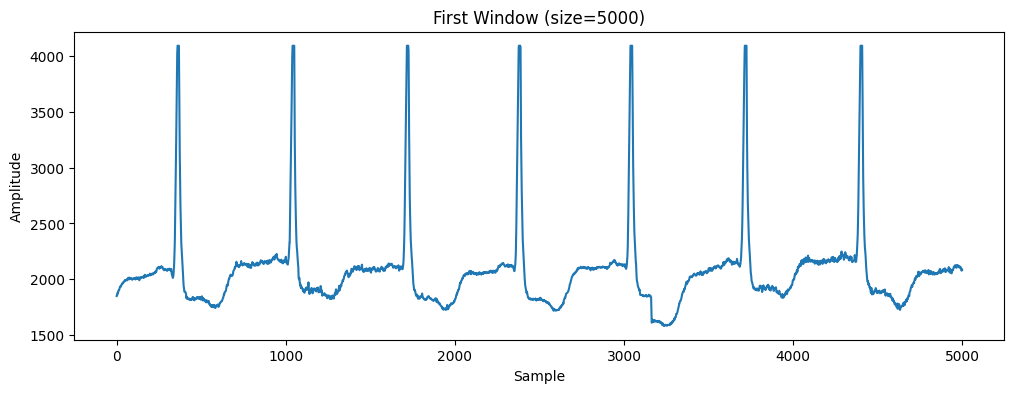

In [38]:
plt.figure(figsize=(12,4))
plt.plot(windows[0])
plt.title(f'First Window (size={WINDOW_SIZE})')
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [39]:
#Window on one full standardized record
windowed_records = window_record(
    record=raw_record,
    window_size=WINDOW_SIZE,
    stride_ratio=STRIDE_RATIO,
)

print("Number of windowed records:", len(windowed_records))
print("Keys in first windowed record:", windowed_records[0].keys())
print("First record window_index:", windowed_records[0]["window_index"])
print("First record window_start/end:", windowed_records[0]["window_start"], windowed_records[0]["window_end"])
print("First record ECG shape:", windowed_records[0]["ecg"].shape)

Number of windowed records: 14
Keys in first windowed record: dict_keys(['record_id', 'source', 'category', 'label', 'ecg', 'pcg', 'fs', 'file_path', 'window_index', 'window_start', 'window_end', 'window_size'])
First record window_index: 0
First record window_start/end: 0 5000
First record ECG shape: (5000,)


### 3.5) RPeak Detection

In [40]:
TEST_WINDOW = windowed_records[0]["ecg"]

TEST_WINDOW_CLEAN = clean_ecg_signal(
    signal=TEST_WINDOW,
    fs=SAMPLING_RATE,
    lowcut=LOWCUT,
    highcut=HIGHCUT,
    notch_freq=NOTCH_FREQ,
    filter_order=FILTER_ORDER,
    quality_factor=QUALITY_FACTOR,
    normalization_method=NORMALIZATION_METHOD,
    eps=EPSILON,
)

In [41]:
rpeak_result = detect_and_extract_beats(
    signal=TEST_WINDOW_CLEAN,
    fs=SAMPLING_RATE,
    pre_samples=RPEAK_PRE_SAMPLES,
    post_samples=RPEAK_POST_SAMPLES,
)

print("R-peak detection success:", rpeak_result["success"])
print("Reason:", rpeak_result["reason"])
print("Number of detected peaks:", rpeak_result["num_rpeaks"])
print("Number of valid peaks:", rpeak_result["num_valid_rpeaks"])

R-peak detection success: True
Reason: ok
Number of detected peaks: 7
Number of valid peaks: 7


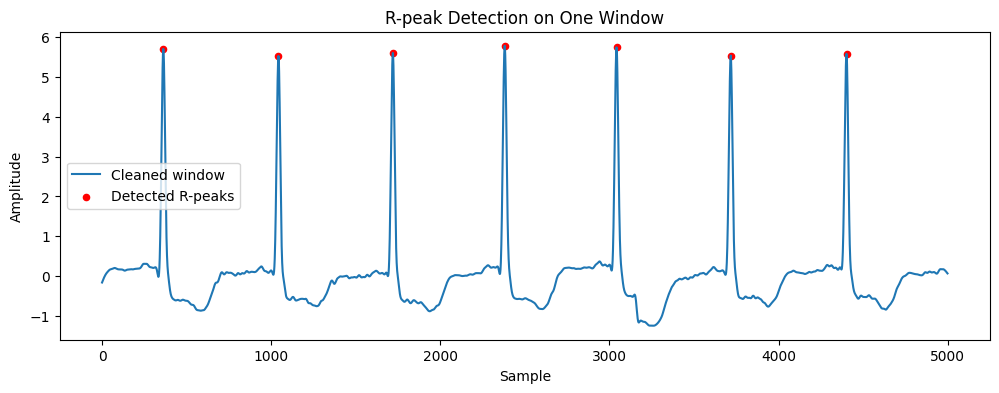

In [42]:
# Plot cleaned window with detected R-peaks

plt.figure(figsize=(12,4))
plt.plot(TEST_WINDOW_CLEAN, label="Cleaned window")

if rpeak_result["success"] and len(rpeak_result["valid_rpeaks"]) > 0:
    plt.scatter(
        rpeak_result["valid_rpeaks"],
        TEST_WINDOW_CLEAN[rpeak_result["valid_rpeaks"]],
        color="red",
        s=20,
        label="Detected R-peaks"
    )

plt.title("R-peak Detection on One Window")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

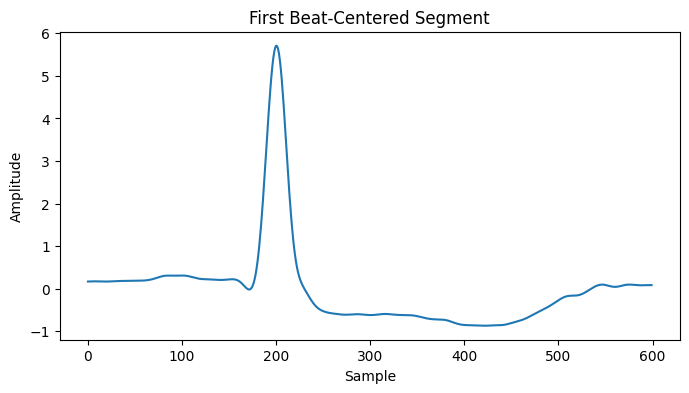

In [43]:
# Plot the first extracted beat snippet
if rpeak_result["beats"].shape[0] > 0:
    plt.figure(figsize=(8,4))
    plt.plot(rpeak_result["beats"][0])
    plt.title("First Beat-Centered Segment")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.show()
else:
    print("No valid beat segments were extracted.")

### 3.6) Metadata

In [44]:
window_meta = build_window_metadata(windowed_records[0], rpeak_result=rpeak_result)
print(window_meta)

{'record_id': 'rcd4f55a8f520250709105600_p1', 'source': 'raw_data_add_v1', 'category': 'ID', 'label': 'ID', 'fs': 1000, 'signal_length': 5000, 'file_path': '/content/drive/My Drive/Duke/Semester 4/data/raw_data_add_v1/rcd4f55a8f520250709105600_p1.csv', 'window_index': 0, 'window_start': 0, 'window_end': 5000, 'window_size': 5000, 'rpeak_success': True, 'rpeak_reason': 'ok', 'num_rpeaks': 7, 'num_valid_rpeaks': 7}


In [45]:
#Convert multiple windowed records to metadata DataFrame

# Run R-peak detection on first few windows for testing
test_windowed_subset = windowed_records[:5]
test_rpeak_results = []

for rec in test_windowed_subset:
    cleaned = clean_ecg_signal(
        signal=rec["ecg"],
        fs=SAMPLING_RATE,
        lowcut=LOWCUT,
        highcut=HIGHCUT,
        notch_freq=NOTCH_FREQ,
        filter_order=FILTER_ORDER,
        quality_factor=QUALITY_FACTOR,
        normalization_method=NORMALIZATION_METHOD,
        eps=EPSILON,
    )

    rp = detect_and_extract_beats(
        signal=cleaned,
        fs=SAMPLING_RATE,
        pre_samples=RPEAK_PRE_SAMPLES,
        post_samples=RPEAK_POST_SAMPLES,
    )
    test_rpeak_results.append(rp)

window_meta_df = windows_to_metadata_df(
    test_windowed_subset,
    rpeak_results=test_rpeak_results
)

window_meta_df.head()

,record_id,source,category,label,fs,signal_length,file_path,window_index,window_start,window_end,window_size,rpeak_success,rpeak_reason,num_rpeaks,num_valid_rpeaks
0,rcd4f55a8f520250709105600_p1,raw_data_add_v1,ID,ID,1000,5000,/content/drive/My Drive/Duke/Semester 4/data/r...,0,0,5000,5000,True,ok,7,7
1,rcd4f55a8f520250709105600_p1,raw_data_add_v1,ID,ID,1000,5000,/content/drive/My Drive/Duke/Semester 4/data/r...,1,2500,7500,5000,True,ok,7,7
2,rcd4f55a8f520250709105600_p1,raw_data_add_v1,ID,ID,1000,5000,/content/drive/My Drive/Duke/Semester 4/data/r...,2,5000,10000,5000,True,ok,7,6
3,rcd4f55a8f520250709105600_p1,raw_data_add_v1,ID,ID,1000,5000,/content/drive/My Drive/Duke/Semester 4/data/r...,3,7500,12500,5000,True,ok,8,7
4,rcd4f55a8f520250709105600_p1,raw_data_add_v1,ID,ID,1000,5000,/content/drive/My Drive/Duke/Semester 4/data/r...,4,10000,15000,5000,True,ok,8,7


## 4) Load Raw ID Data

### 4.1) Load dump_duke

In [46]:
#Discover dump_duke files

dump_duke_files = list_json_files(ID_DUMP_DUKE_DIR)

print("Total dump_duke files:", len(dump_duke_files))
print("Example file:", dump_duke_files[0])

Total dump_duke files: 970
Example file: /content/drive/My Drive/Duke/Semester 4/data/dump_duke/AF/CVD_rcd0ac95dacb020210706093525.json


In [47]:
# Load dump_duke records

dump_duke_records = []

for filepath in dump_duke_files:

    json_data = load_json_file(filepath)

    record = build_record_dict_from_dump_duke(
        filepath,
        json_data
    )

    dump_duke_records.append(record)

print("Loaded records:", len(dump_duke_records))

Loaded records: 970


In [48]:
#Make metadata table
dump_duke_metadata = records_to_metadata_df(dump_duke_records)

print("Metadata rows:", len(dump_duke_metadata))

dump_duke_metadata.head()

Metadata rows: 970


,record_id,source,category,label,fs,signal_length,file_path
0,CVD_rcd0ac95dacb020210706093525,dump_duke,AF,ID,1000,22272,/content/drive/My Drive/Duke/Semester 4/data/d...
1,CVD_rcd0ac95dacb020210706093637,dump_duke,AF,ID,1000,31744,/content/drive/My Drive/Duke/Semester 4/data/d...
2,CVD_rcd0ac95dacb020210706093709,dump_duke,AF,ID,1000,51200,/content/drive/My Drive/Duke/Semester 4/data/d...
3,CVD_rcd18f4d62f7f20180720144726,dump_duke,AF,ID,1000,60160,/content/drive/My Drive/Duke/Semester 4/data/d...
4,CVD_rcd1AB48FADBC20210421203610,dump_duke,AF,ID,1000,60416,/content/drive/My Drive/Duke/Semester 4/data/d...


### 4.2) Load raw_add_data_v1

In [49]:
#Get raw data
raw_data_files = list_csv_files(ID_RAW_DATA_DIR)

print("Total raw_data_add_v1 files:", len(raw_data_files))
print("Example file:", raw_data_files[0])

Total raw_data_add_v1 files: 5519
Example file: /content/drive/My Drive/Duke/Semester 4/data/raw_data_add_v1/rcd4f55a8f520250709105600_p1.csv


In [50]:
#load records
raw_data_records = []

for filepath in raw_data_files:
  df = pd.read_csv(filepath)

  record = build_record_dict_from_csv(
      filepath,
      df,
      source_name='raw_data_add_v1',
      label='ID'
  )
  raw_data_records.append(record)

print("Loaded raw_data_add_v1 records:", len(raw_data_records))

Loaded raw_data_add_v1 records: 5519


In [51]:
#Metadata table

raw_data_metadata = records_to_metadata_df(raw_data_records)
print('Metadata rows: ', len(raw_data_metadata))

raw_data_metadata.head()

save_metadata(raw_data_metadata, "raw_data_metadata")

Metadata rows:  5519
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/raw_data_metadata.csv  (5519 rows)


### 4.3) Merge ID Data

In [52]:
#Merge ID datasets
id_records = dump_duke_records + raw_data_records

print('Total ID records:', len(id_records))

Total ID records: 6489


In [53]:
#Merge metadata tables
id_metadata = pd.concat(
    [dump_duke_metadata, raw_data_metadata],
    ignore_index=True
)

print('Metadata rows:', len(id_metadata))

save_metadata(id_metadata, "id_metadata")

Metadata rows: 6489
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_metadata.csv  (6489 rows)


In [54]:
#Check distributions
id_metadata['source'].value_counts()

,count
source,
raw_data_add_v1,5519
dump_duke,970


In [55]:
id_metadata['label'].value_counts()

,count
label,
ID,6489


In [56]:
id_metadata['category'].value_counts()

,count
category,
ID,5519
AF,519
PAC,222
NORMAL,194
PAC_PVC,18
AF_PVC,15
AF_PAC,2


In [57]:
id_metadata['fs'].value_counts()

,count
fs,
1000,6489


## 5) Load Raw OOD Data

### 5.1) Load ECG_OOD

In [58]:
ecg_ood_files = list_csv_files(OOD_DATA_DIR)

print('Total ECG_OOD files:', len(ecg_ood_files))
print('Example file:', ecg_ood_files[0])

Total ECG_OOD files: 2884
Example file: /content/drive/My Drive/Duke/Semester 4/data/ECG_OOD/data/ecg_invalid_0603/raw/rcd0aba8b7420230829135510_p11.csv


In [60]:
#Load records
ecg_ood_records = []

for filepath in ecg_ood_files:

    try:
        df = pd.read_csv(filepath)

        record = build_record_dict_from_csv(
            filepath,
            df,
            source_name="ECG_OOD",
            label="OOD"
        )

        ecg_ood_records.append(record)

    except Exception as e:
        print("Skipping file:", filepath)
        print("Reason:", e)

print("Loaded OOD records:", len(ecg_ood_records))

Skipping file: /content/drive/My Drive/Duke/Semester 4/data/ECG_OOD/data/ecg_invalid_0603/raw/rcd8949746420230209171048_p1.csv
Reason: No columns to parse from file
Loaded OOD records: 2883


In [61]:
#Build metadata
ecg_ood_metadata = records_to_metadata_df(ecg_ood_records)

print("Metadata rows:", len(ecg_ood_metadata))

ecg_ood_metadata.head()

save_metadata(ecg_ood_metadata, "ecg_ood_metadata")

Metadata rows: 2883
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/ecg_ood_metadata.csv  (2883 rows)


### 5.2) Merge OOD Data

In [62]:
ood_records = ecg_ood_records

ood_metadata = ecg_ood_metadata

print("Total OOD records:", len(ood_records))

Total OOD records: 2883


## 6) Sanity Checks

In [63]:
#Dataset sizes
print('ID records:', len(id_records))
print('OOD records:', len(ood_records))

ID records: 6489
OOD records: 2883


### 6.1) Visualizations

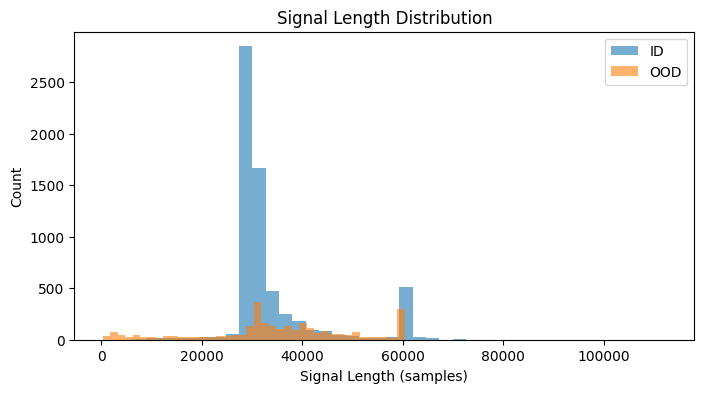

In [64]:
#Signal length distribution
id_lengths = [len(r["ecg"]) for r in id_records]
ood_lengths = [len(r["ecg"]) for r in ood_records]

plt.figure(figsize=(8,4))

plt.hist(id_lengths, bins=40, alpha=0.6, label="ID")
plt.hist(ood_lengths, bins=40, alpha=0.6, label="OOD")

plt.title("Signal Length Distribution")
plt.xlabel("Signal Length (samples)")
plt.ylabel("Count")
plt.legend()

plt.show()

## 7) Signal Cleaning + Standardization

### 7.1) Extract Single Lead Data

In [65]:
#Combine all raw records for preprocessing
all_records = id_records + ood_records

print('Total records before single-lead extraction:', len(all_records))

Total records before single-lead extraction: 9372


In [66]:
#Make sure every ECG signal is 1D single-lead
single_lead_records = []
bad_shape_records = []

for record in all_records:
    try:
        single_lead_ecg = ensure_1d_signal(record["ecg"], signal_name="ecg")

        updated_record = dict(record)
        updated_record["ecg"] = single_lead_ecg

        single_lead_records.append(updated_record)

    except Exception as e:
        bad_record = dict(record)
        bad_record["shape_error"] = str(e)
        bad_shape_records.append(bad_record)

print("Single-lead valid records:", len(single_lead_records))
print("Bad-shape records:", len(bad_shape_records))

Single-lead valid records: 9372
Bad-shape records: 0


In [67]:
#Check of ECG shapes
unique_shapes = sorted(set([r["ecg"].shape for r in single_lead_records]))
print("Unique ECG shapes after extraction:", unique_shapes[:10])
print("Number of unique shapes:", len(unique_shapes))

Unique ECG shapes after extraction: [(255,), (511,), (767,), (1023,), (1279,), (1535,), (1791,), (2047,), (2303,), (2559,)]
Number of unique shapes: 506


In [68]:
#Split back into ID/OOD
id_single_lead_records = [r for r in single_lead_records if r["label"] == "ID"]
ood_single_lead_records = [r for r in single_lead_records if r["label"] == "OOD"]

print("ID single-lead records:", len(id_single_lead_records))
print("OOD single-lead records:", len(ood_single_lead_records))

ID single-lead records: 6489
OOD single-lead records: 2883


In [69]:
#Single-lead metadata
single_lead_metadata = records_to_metadata_df(single_lead_records)

print("Metadata rows:", len(single_lead_metadata))
single_lead_metadata.head()

save_metadata(single_lead_metadata, "single_lead_metadata")

Metadata rows: 9372
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/single_lead_metadata.csv  (9372 rows)


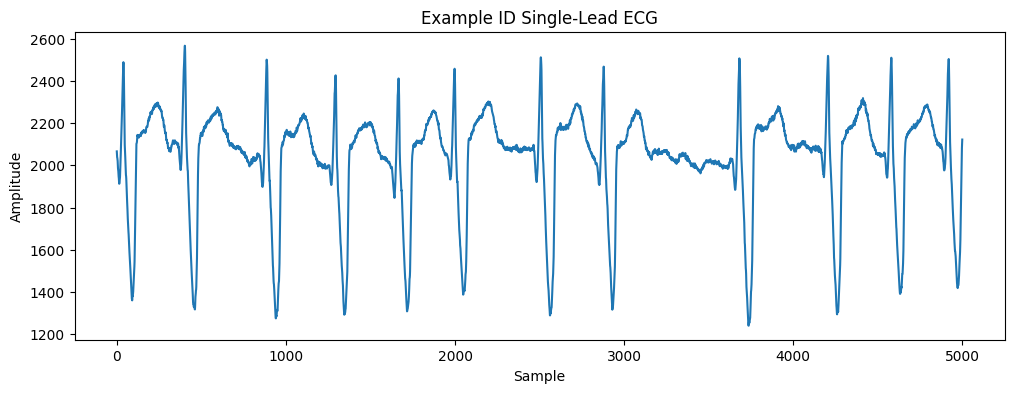

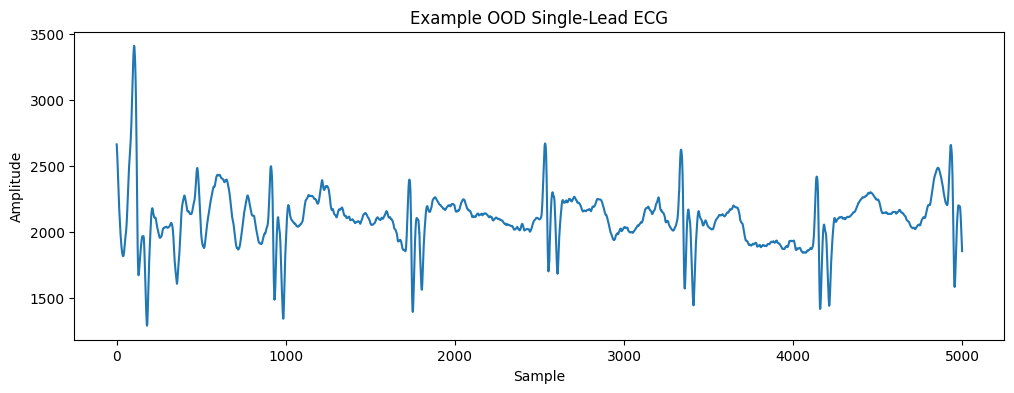

In [70]:
#Visual sanity check
plt.figure(figsize=(12,4))
plt.plot(id_single_lead_records[0]["ecg"][:5000])
plt.title("Example ID Single-Lead ECG")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(ood_single_lead_records[1]["ecg"][:5000])
plt.title("Example OOD Single-Lead ECG")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

### 7.2) Apply Filters

In [71]:
#Apply filters to single-lead signals
filtered_records = []
filter_failed_records = []

for record in single_lead_records:
    try:
        filtered_ecg = clean_ecg_signal(
            signal=record["ecg"],
            fs=SAMPLING_RATE,
            lowcut=LOWCUT,
            highcut=HIGHCUT,
            notch_freq=NOTCH_FREQ,
            filter_order=FILTER_ORDER,
            quality_factor=QUALITY_FACTOR,
            apply_bandpass=True,
            apply_notch=True,
            normalize=False,   # normalization happens later in Section 10
            normalization_method=NORMALIZATION_METHOD,
            eps=EPSILON,
        )

        updated_record = dict(record)
        updated_record["ecg"] = filtered_ecg
        filtered_records.append(updated_record)

    except Exception as e:
        bad_record = dict(record)
        bad_record["filter_error"] = str(e)
        filter_failed_records.append(bad_record)

print("Filtered records:", len(filtered_records))
print("Filter-failed records:", len(filter_failed_records))


Filtered records: 9372
Filter-failed records: 0


In [72]:
#Split filtered back into ID/OOD
id_filtered_records = [r for r in filtered_records if r["label"] == "ID"]
ood_filtered_records = [r for r in filtered_records if r["label"] == "OOD"]

print("Filtered ID records:", len(id_filtered_records))
print("Filtered OOD records:", len(ood_filtered_records))

Filtered ID records: 6489
Filtered OOD records: 2883


In [73]:
#Buld metadata
filtered_metadata = records_to_metadata_df(filtered_records)

print("Metadata rows:", len(filtered_metadata))
filtered_metadata.head()

save_metadata(filtered_metadata, "filtered_metadata")

Metadata rows: 9372
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/filtered_metadata.csv  (9372 rows)


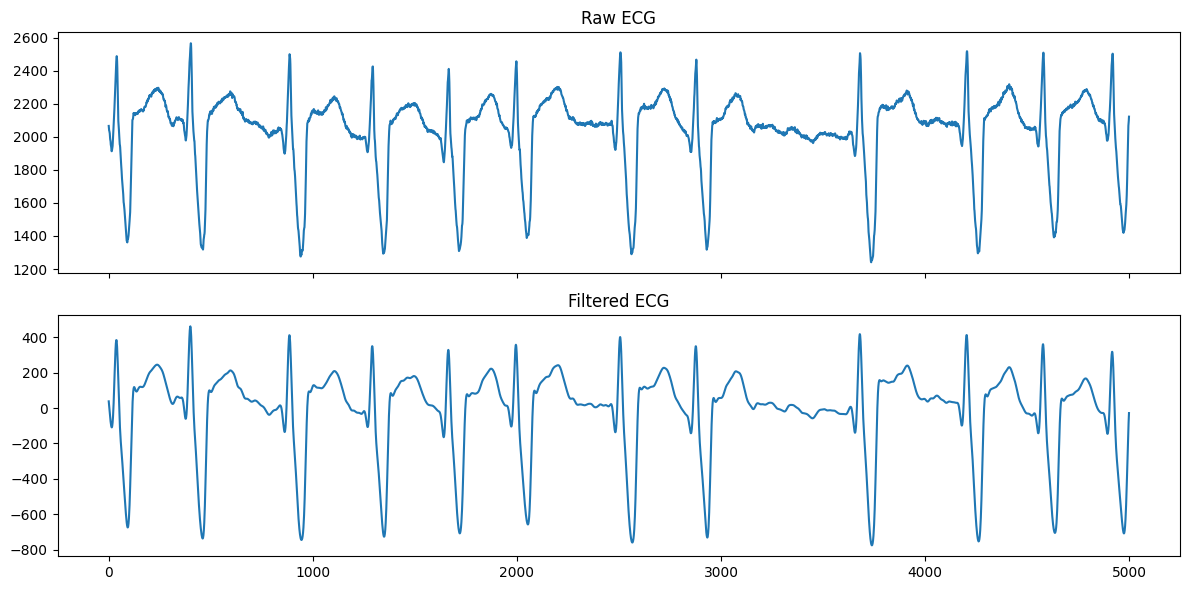

In [74]:
#Example OOD raw vs filtered
example_raw = single_lead_records[0]['ecg']
example_filtered = filtered_records[0]['ecg']

fig, axes = plt.subplots(2,1,figsize=(12,6), sharex=True)
axes[0].plot(example_raw[:5000])
axes[0].set_title("Raw ECG")

axes[1].plot(example_filtered[:5000])
axes[1].set_title("Filtered ECG")

plt.tight_layout()
plt.show()

### 7.3) Handle Invalid/Too-Short Signals

In [75]:
#Validate filtered signals
valid_records = []
invalid_records = []

for record in filtered_records:
    valid, reason = is_valid_signal(
        signal=record["ecg"],
        min_length=MIN_SIGNAL_LENGTH,
        max_nan_ratio=MAX_NAN_RATIO,
    )

    if valid:
        updated_record = dict(record)
        updated_record["qc_status"] = "valid"
        updated_record["qc_reason"] = "ok"
        valid_records.append(updated_record)
    else:
        bad_record = dict(record)
        bad_record["qc_status"] = "invalid"
        bad_record["qc_reason"] = reason
        invalid_records.append(bad_record)

print("Valid records:", len(valid_records))
print("Invalid records:", len(invalid_records))

Valid records: 9087
Invalid records: 285


In [76]:
#split valid/invalid by label
id_valid_records = [r for r in valid_records if r["label"] == "ID"]
ood_valid_records = [r for r in valid_records if r["label"] == "OOD"]

id_invalid_records = [r for r in invalid_records if r["label"] == "ID"]
ood_invalid_records = [r for r in invalid_records if r["label"] == "OOD"]

print("Valid ID records:", len(id_valid_records))
print("Valid OOD records:", len(ood_valid_records))
print("Invalid ID records:", len(id_invalid_records))
print("Invalid OOD records:", len(ood_invalid_records))

Valid ID records: 6471
Valid OOD records: 2616
Invalid ID records: 18
Invalid OOD records: 267


In [77]:
#Failure summary
if len(invalid_records) > 0:
    invalid_df = pd.DataFrame([
        {
            "record_id": r.get("record_id"),
            "source": r.get("source"),
            "label": r.get("label"),
            "category": r.get("category"),
            "qc_reason": r.get("qc_reason"),
            "signal_length": len(r["ecg"]),
            "file_path": r.get("file_path"),
        }
        for r in invalid_records
    ])

    print(invalid_df["qc_reason"].value_counts())
    invalid_df.head()
else:
    print("No invalid records found.")

qc_reason
too_short    285
Name: count, dtype: int64


In [78]:
#Metadata for valid/invalid sets
valid_metadata = records_to_metadata_df(valid_records)
invalid_metadata = records_to_metadata_df(invalid_records) if len(invalid_records) > 0 else pd.DataFrame()

print("Valid metadata rows:", len(valid_metadata))
print("Invalid metadata rows:", len(invalid_metadata))

save_metadata(valid_metadata, "valid_metadata")
save_metadata(invalid_metadata, "invalid_metadata")

Valid metadata rows: 9087
Invalid metadata rows: 285
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/valid_metadata.csv  (9087 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/invalid_metadata.csv  (285 rows)


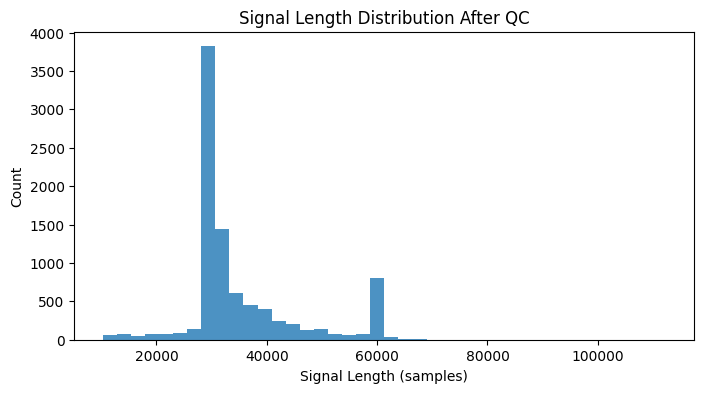

In [79]:
#Signal length sanity check
valid_lengths = [len(r["ecg"]) for r in valid_records]

plt.figure(figsize=(8,4))
plt.hist(valid_lengths, bins=40, alpha=0.8)
plt.title("Signal Length Distribution After QC")
plt.xlabel("Signal Length (samples)")
plt.ylabel("Count")
plt.show()

### 7.4) Standardize Output Shapes

In [80]:
def add_channel_dim(signal):
    """
    Convert a 1D ECG signal of shape (T,) to (T, 1).
    """
    signal = np.asarray(signal, dtype=np.float32)

    if signal.ndim == 1:
        return signal[:, None]

    if signal.ndim == 2 and signal.shape[1] == 1:
        return signal.astype(np.float32)

    raise ValueError(f"Expected shape (T,) or (T,1), got {signal.shape}")

In [81]:
#Standardize output shape for valid records
standardized_records = []
shape_failed_records = []

for record in valid_records:
    try:
        standardized_ecg = add_channel_dim(record["ecg"])

        updated_record = dict(record)
        updated_record["ecg"] = standardized_ecg
        updated_record["ecg_shape"] = standardized_ecg.shape

        standardized_records.append(updated_record)

    except Exception as e:
        bad_record = dict(record)
        bad_record["shape_error"] = str(e)
        shape_failed_records.append(bad_record)

print("Standardized records:", len(standardized_records))
print("Shape-failed records:", len(shape_failed_records))

Standardized records: 9087
Shape-failed records: 0


In [82]:
#Split back into ID/OOD
id_standardized_records = [r for r in standardized_records if r["label"] == "ID"]
ood_standardized_records = [r for r in standardized_records if r["label"] == "OOD"]

print("Standardized ID records:", len(id_standardized_records))
print("Standardized OOD records:", len(ood_standardized_records))

Standardized ID records: 6471
Standardized OOD records: 2616


In [83]:
#Metadata
standardized_metadata = records_to_metadata_df(standardized_records)
standardized_metadata["ecg_shape"] = [r["ecg_shape"] for r in standardized_records]

id_standardized_metadata = standardized_metadata[standardized_metadata["label"] == "ID"].reset_index(drop=True)
ood_standardized_metadata = standardized_metadata[standardized_metadata["label"] == "OOD"].reset_index(drop=True)

print("Standardized metadata rows:", len(standardized_metadata))
print("ID standardized metadata rows:", len(id_standardized_metadata))
print("OOD standardized metadata rows:", len(ood_standardized_metadata))

standardized_metadata.head()

save_metadata(standardized_metadata, "standardized_metadata")

Standardized metadata rows: 9087
ID standardized metadata rows: 6471
OOD standardized metadata rows: 2616
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/standardized_metadata.csv  (9087 rows)


## 8) Record-Level Train/Val/Test Splits

### 8.1) ID Splits

In [84]:
#Build record_id list for ID records
id_record_ids = [r["record_id"] for r in id_standardized_records]

print("Total ID records:", len(id_record_ids))
print("Unique ID record_ids:", len(set(id_record_ids)))

Total ID records: 6471
Unique ID record_ids: 6471


In [85]:
#Train/temp split
train_ids, temp_ids = train_test_split(
    id_record_ids,
    test_size=(1.0 - TRAIN_RATIO),
    random_state=RANDOM_SEED,
    shuffle=True
)

print("Train IDs:", len(train_ids))
print("Temp IDs:", len(temp_ids))

Train IDs: 4529
Temp IDs: 1942


In [86]:
#Temp/val split
val_fraction_of_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=(1.0 - val_fraction_of_temp),
    random_state=RANDOM_SEED,
    shuffle=True
)

print("Val IDs:", len(val_ids))
print("Test IDs:", len(test_ids))

Val IDs: 971
Test IDs: 971


In [87]:
#convert to sets
train_id_set = set(train_ids)
val_id_set = set(val_ids)
test_id_set = set(test_ids)

In [88]:
#Split ID records
id_train_records = [r for r in id_standardized_records if r["record_id"] in train_id_set]
id_val_records   = [r for r in id_standardized_records if r["record_id"] in val_id_set]
id_test_records  = [r for r in id_standardized_records if r["record_id"] in test_id_set]

print("ID train records:", len(id_train_records))
print("ID val records:", len(id_val_records))
print("ID test records:", len(id_test_records))

ID train records: 4529
ID val records: 971
ID test records: 971


### 8.2) OOD Splits

In [89]:
#OOD is test-only
ood_test_records = ood_standardized_records

print("OOD test records:", len(ood_test_records))

OOD test records: 2616


### 8.3) Save Splits

In [90]:
#Build split metadata
id_train_metadata = records_to_metadata_df(id_train_records)
id_val_metadata   = records_to_metadata_df(id_val_records)
id_test_metadata  = records_to_metadata_df(id_test_records)
ood_test_metadata = records_to_metadata_df(ood_test_records)

print("ID train metadata rows:", len(id_train_metadata))
print("ID val metadata rows:", len(id_val_metadata))
print("ID test metadata rows:", len(id_test_metadata))
print("OOD test metadata rows:", len(ood_test_metadata))

save_metadata(id_train_metadata, "id_train_metadata")
save_metadata(id_val_metadata, "id_val_metadata")
save_metadata(id_test_metadata, "id_test_metadata")
save_metadata(ood_test_metadata, "ood_test_metadata")

ID train metadata rows: 4529
ID val metadata rows: 971
ID test metadata rows: 971
OOD test metadata rows: 2616
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_train_metadata.csv  (4529 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_val_metadata.csv  (971 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_test_metadata.csv  (971 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/ood_test_metadata.csv  (2616 rows)


In [91]:
#Save split manifest
split_manifest = {
    "train_record_ids": sorted(list(train_id_set)),
    "val_record_ids": sorted(list(val_id_set)),
    "test_record_ids": sorted(list(test_id_set)),
    "ood_record_ids": sorted([r["record_id"] for r in ood_test_records]),
    "random_seed": RANDOM_SEED,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
}

print("Split manifest keys:", split_manifest.keys())

Split manifest keys: dict_keys(['train_record_ids', 'val_record_ids', 'test_record_ids', 'ood_record_ids', 'random_seed', 'train_ratio', 'val_ratio', 'test_ratio'])


In [92]:
#Category distribution check
print("Train category distribution:")
print(id_train_metadata["category"].value_counts())

print("\nVal category distribution:")
print(id_val_metadata["category"].value_counts())

print("\nTest category distribution:")
print(id_test_metadata["category"].value_counts())

Train category distribution:
category
ID         3863
AF          337
PAC         161
NORMAL      142
PAC_PVC      13
AF_PVC       11
AF_PAC        2
Name: count, dtype: int64

Val category distribution:
category
ID         815
AF          87
PAC         38
NORMAL      28
PAC_PVC      2
AF_PVC       1
Name: count, dtype: int64

Test category distribution:
category
ID         823
AF          95
NORMAL      24
PAC         23
AF_PVC       3
PAC_PVC      3
Name: count, dtype: int64


In [93]:
#Overlap check
print("Train/Val overlap:", len(train_id_set.intersection(val_id_set)))
print("Train/Test overlap:", len(train_id_set.intersection(test_id_set)))
print("Val/Test overlap:", len(val_id_set.intersection(test_id_set)))

Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


### Save Record-Level Cleaned Dataset

In [94]:
#Save datasets
np.save(CLEANED_DATA_DIR / "id_train_records.npy", id_train_records, allow_pickle=True)
np.save(CLEANED_DATA_DIR / "id_val_records.npy", id_val_records, allow_pickle=True)
np.save(CLEANED_DATA_DIR / "id_test_records.npy", id_test_records, allow_pickle=True)
np.save(CLEANED_DATA_DIR / "ood_test_records.npy", ood_test_records, allow_pickle=True)

print("Cleaned record-level datasets saved.")

Cleaned record-level datasets saved.


In [95]:
allow_pickle = True

In [96]:
#Save split manifest
with open(PREPARED_DATA_DIR / "split_manifest.json", "w") as f:
    json.dump(split_manifest, f, indent=4)

print("Split manifest saved.")

Split manifest saved.


## 9) Windowing

In [97]:
#Load in data
allow_pickle = True

id_train_records = np.load(CLEANED_DATA_DIR / "id_train_records.npy", allow_pickle=True).tolist()
id_val_records = np.load(CLEANED_DATA_DIR / "id_val_records.npy", allow_pickle=True).tolist()
id_test_records = np.load(CLEANED_DATA_DIR / "id_test_records.npy", allow_pickle=True).tolist()
ood_test_records = np.load(CLEANED_DATA_DIR / "ood_test_records.npy", allow_pickle=True).tolist()

print("Train records:", len(id_train_records))
print("Val records:", len(id_val_records))
print("Test records:", len(id_test_records))
print("OOD test records:", len(ood_test_records))

Train records: 4529
Val records: 971
Test records: 971
OOD test records: 2616


In [98]:
example = id_train_records[0]

print(example.keys())
print(example['ecg'].shape)

dict_keys(['record_id', 'source', 'category', 'label', 'ecg', 'pcg', 'fs', 'file_path', 'qc_status', 'qc_reason', 'ecg_shape'])
(22272, 1)


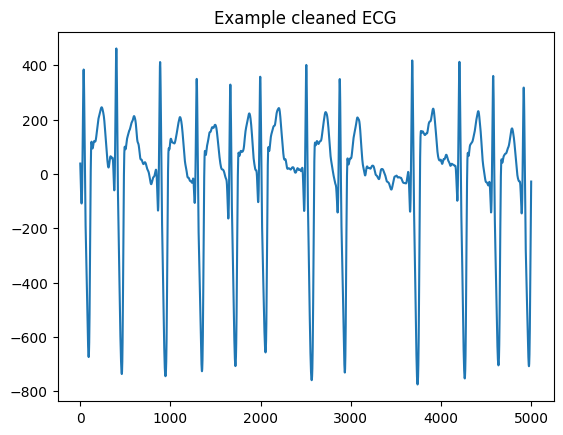

In [99]:
plt.plot(example['ecg'][:5000,0])
plt.title('Example cleaned ECG')
plt.show()

### 9.1) Windowing

In [100]:
windowed_records_by_size = {}
windowed_metadata_by_size = {}

split_record_map = {
    "id_train": id_train_records,
    "id_val": id_val_records,
    "id_test": id_test_records,
    "ood_test": ood_test_records,
}

In [101]:
for window_size in WINDOW_SIZES:
    print(f"\nProcessing window size: {window_size}")

    windowed_records_by_size[window_size] = {}
    windowed_metadata_by_size[window_size] = {}

    for split_name, records in split_record_map.items():
        split_windowed_records = []

        for record in records:
            # record["ecg"] is currently shape (T, 1), convert to 1D for windowing
            record_1d = dict(record)
            record_1d["ecg"] = np.asarray(record["ecg"]).squeeze()

            record_windows = window_record(
                record=record_1d,
                window_size=window_size,
                stride_ratio=WINDOW_STRIDE_RATIO
            )

            # put channel dim back so final shape is (window_size, 1)
            for wrec in record_windows:
                wrec["ecg"] = np.asarray(wrec["ecg"], dtype=np.float32)[:, None]
                wrec["ecg_shape"] = wrec["ecg"].shape

            split_windowed_records.extend(record_windows)

        split_windowed_metadata = records_to_metadata_df(split_windowed_records)
        split_windowed_metadata["window_index"] = [r["window_index"] for r in split_windowed_records]
        split_windowed_metadata["window_start"] = [r["window_start"] for r in split_windowed_records]
        split_windowed_metadata["window_end"] = [r["window_end"] for r in split_windowed_records]
        split_windowed_metadata["window_size"] = [r["window_size"] for r in split_windowed_records]
        split_windowed_metadata["ecg_shape"] = [r["ecg_shape"] for r in split_windowed_records]

        windowed_records_by_size[window_size][split_name] = split_windowed_records
        windowed_metadata_by_size[window_size][split_name] = split_windowed_metadata

        print(f"{split_name}: {len(split_windowed_records)} windows")


Processing window size: 2500
id_train: 116315 windows
id_val: 25081 windows
id_test: 25139 windows
ood_test: 75852 windows

Processing window size: 5000
id_train: 54478 windows
id_val: 11727 windows
id_test: 11780 windows
ood_test: 36005 windows

Processing window size: 10000
id_train: 23553 windows
id_val: 5054 windows
id_test: 5104 windows
ood_test: 16114 windows


In [102]:
#Sanity Checks
for window_size in WINDOW_SIZES:
    print(f"\nWindow size = {window_size}")
    for split_name in ["id_train", "id_val", "id_test", "ood_test"]:
        records = windowed_records_by_size[window_size][split_name]
        print(split_name, "num windows =", len(records))

        if len(records) > 0:
            print(" example shape:", records[0]["ecg"].shape)


Window size = 2500
id_train num windows = 116315
 example shape: (2500, 1)
id_val num windows = 25081
 example shape: (2500, 1)
id_test num windows = 25139
 example shape: (2500, 1)
ood_test num windows = 75852
 example shape: (2500, 1)

Window size = 5000
id_train num windows = 54478
 example shape: (5000, 1)
id_val num windows = 11727
 example shape: (5000, 1)
id_test num windows = 11780
 example shape: (5000, 1)
ood_test num windows = 36005
 example shape: (5000, 1)

Window size = 10000
id_train num windows = 23553
 example shape: (10000, 1)
id_val num windows = 5054
 example shape: (10000, 1)
id_test num windows = 5104
 example shape: (10000, 1)
ood_test num windows = 16114
 example shape: (10000, 1)


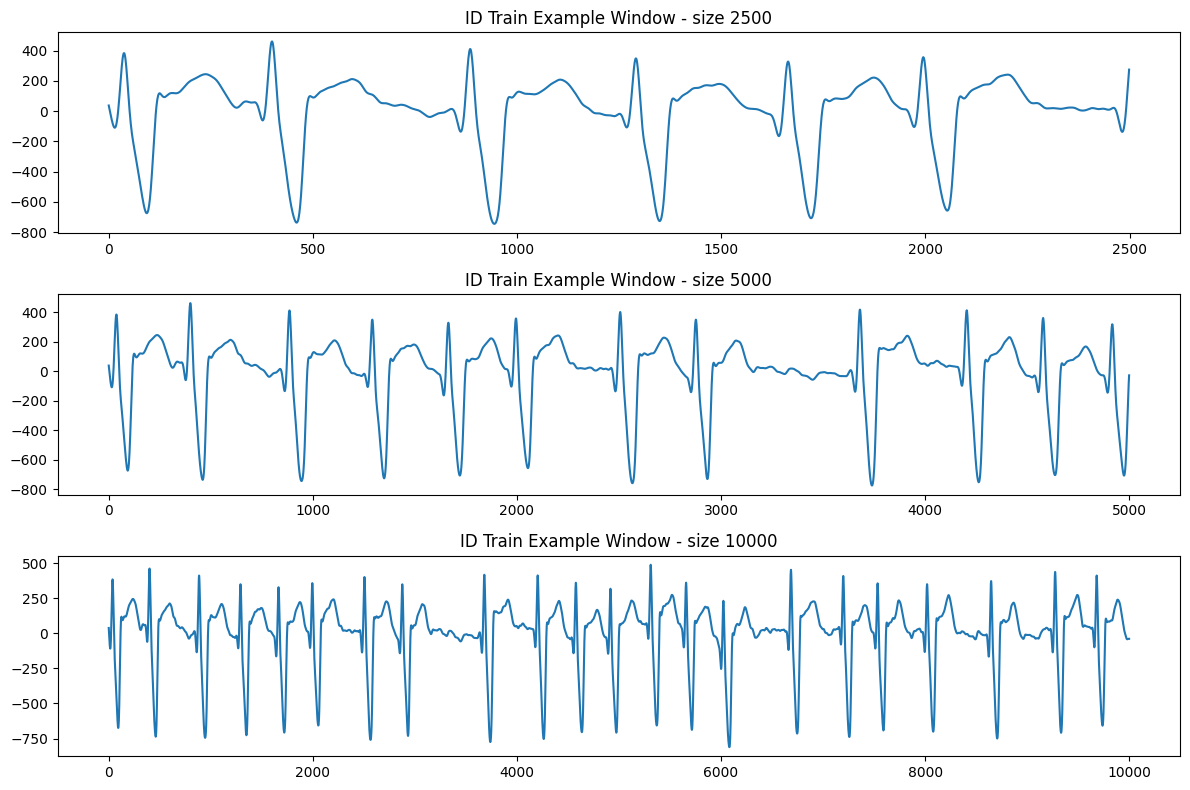

In [103]:
#Visual sanity check
fig, axes = plt.subplots(len(WINDOW_SIZES), 1, figsize=(12, 8))

for i, window_size in enumerate(WINDOW_SIZES):
    example = windowed_records_by_size[window_size]["id_train"][0]["ecg"]
    axes[i].plot(example[:, 0])
    axes[i].set_title(f"ID Train Example Window - size {window_size}")

plt.tight_layout()
plt.show()

In [105]:
#Save metadata
for window_size in WINDOW_SIZES:
    for split_name in ["id_train", "id_val", "id_test", "ood_test"]:

        key = f"{split_name}_window_{window_size}_metadata"
        df = windowed_metadata_by_size[window_size][split_name]

        # Save to disk immediately
        save_metadata(df, key)

print("Saved windowed metadata tables.")

Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_train_window_2500_metadata.csv  (116315 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_val_window_2500_metadata.csv  (25081 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_test_window_2500_metadata.csv  (25139 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/ood_test_window_2500_metadata.csv  (75852 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_train_window_5000_metadata.csv  (54478 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_val_window_5000_metadata.csv  (11727 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_test_window_5000_metadata.c

## 10) Normalization

### 10.1) Apply Normalization to Splits

In [106]:
normalized_records_by_size = {}
final_arrays_by_size = {}
final_metadata_by_size = {}

In [107]:
for window_size in WINDOW_SIZES:
    print(f"\nNormalizing window size: {window_size}")

    normalized_records_by_size[window_size] = {}
    final_arrays_by_size[window_size] = {}
    final_metadata_by_size[window_size] = {}

    for split_name in ["id_train", "id_val", "id_test", "ood_test"]:
        split_records = windowed_records_by_size[window_size][split_name]
        split_normalized_records = []

        for record in split_records:
            signal = np.asarray(record["ecg"], dtype=np.float32).squeeze()

            norm_signal = normalize_signal(
                signal,
                method=NORMALIZATION_METHOD,
                eps=EPSILON
            )

            updated_record = dict(record)
            updated_record["ecg"] = norm_signal[:, None]   # keep shape (T,1)
            updated_record["ecg_shape"] = updated_record["ecg"].shape

            split_normalized_records.append(updated_record)

        # Save normalized record dicts
        normalized_records_by_size[window_size][split_name] = split_normalized_records

        # Build final X array
        X = np.stack([r["ecg"] for r in split_normalized_records]).astype(np.float32)
        final_arrays_by_size[window_size][split_name] = X

        # Build metadata
        meta_df = records_to_metadata_df(split_normalized_records)
        meta_df["window_index"] = [r["window_index"] for r in split_normalized_records]
        meta_df["window_start"] = [r["window_start"] for r in split_normalized_records]
        meta_df["window_end"] = [r["window_end"] for r in split_normalized_records]
        meta_df["window_size"] = [r["window_size"] for r in split_normalized_records]
        meta_df["ecg_shape"] = [r["ecg_shape"] for r in split_normalized_records]

        final_metadata_by_size[window_size][split_name] = meta_df

        print(f"{split_name}: X shape = {X.shape}")


Normalizing window size: 2500
id_train: X shape = (116315, 2500, 1)
id_val: X shape = (25081, 2500, 1)
id_test: X shape = (25139, 2500, 1)
ood_test: X shape = (75852, 2500, 1)

Normalizing window size: 5000
id_train: X shape = (54478, 5000, 1)
id_val: X shape = (11727, 5000, 1)
id_test: X shape = (11780, 5000, 1)
ood_test: X shape = (36005, 5000, 1)

Normalizing window size: 10000
id_train: X shape = (23553, 10000, 1)
id_val: X shape = (5054, 10000, 1)
id_test: X shape = (5104, 10000, 1)
ood_test: X shape = (16114, 10000, 1)


In [108]:
#Sanity checks
for window_size in WINDOW_SIZES:
    print(f"\nWindow size = {window_size}")
    for split_name in ["id_train", "id_val", "id_test", "ood_test"]:
        X = final_arrays_by_size[window_size][split_name]

        print(
            split_name,
            "| shape:", X.shape,
            "| mean:", np.mean(X),
            "| std:", np.std(X)
        )


Window size = 2500
id_train | shape: (116315, 2500, 1) | mean: -3.2796261e-12 | std: 0.9999991
id_val | shape: (25081, 2500, 1) | mean: -2.6768737e-12 | std: 1.0000005
id_test | shape: (25139, 2500, 1) | mean: 6.1304655e-12 | std: 1.0
ood_test | shape: (75852, 2500, 1) | mean: -5.053272e-11 | std: 1.0000007

Window size = 5000
id_train | shape: (54478, 5000, 1) | mean: 1.0013248e-11 | std: 1.0000017
id_val | shape: (11727, 5000, 1) | mean: 2.7714863e-11 | std: 1.0
id_test | shape: (11780, 5000, 1) | mean: -9.986865e-11 | std: 1.0000002
ood_test | shape: (36005, 5000, 1) | mean: -1.7799448e-12 | std: 1.0000001

Window size = 10000
id_train | shape: (23553, 10000, 1) | mean: -2.6432242e-11 | std: 0.99999946
id_val | shape: (5054, 10000, 1) | mean: -1.4808936e-10 | std: 1.0000007
id_test | shape: (5104, 10000, 1) | mean: -1.6741619e-11 | std: 1.0000004
ood_test | shape: (16114, 10000, 1) | mean: -7.537543e-11 | std: 0.99999887


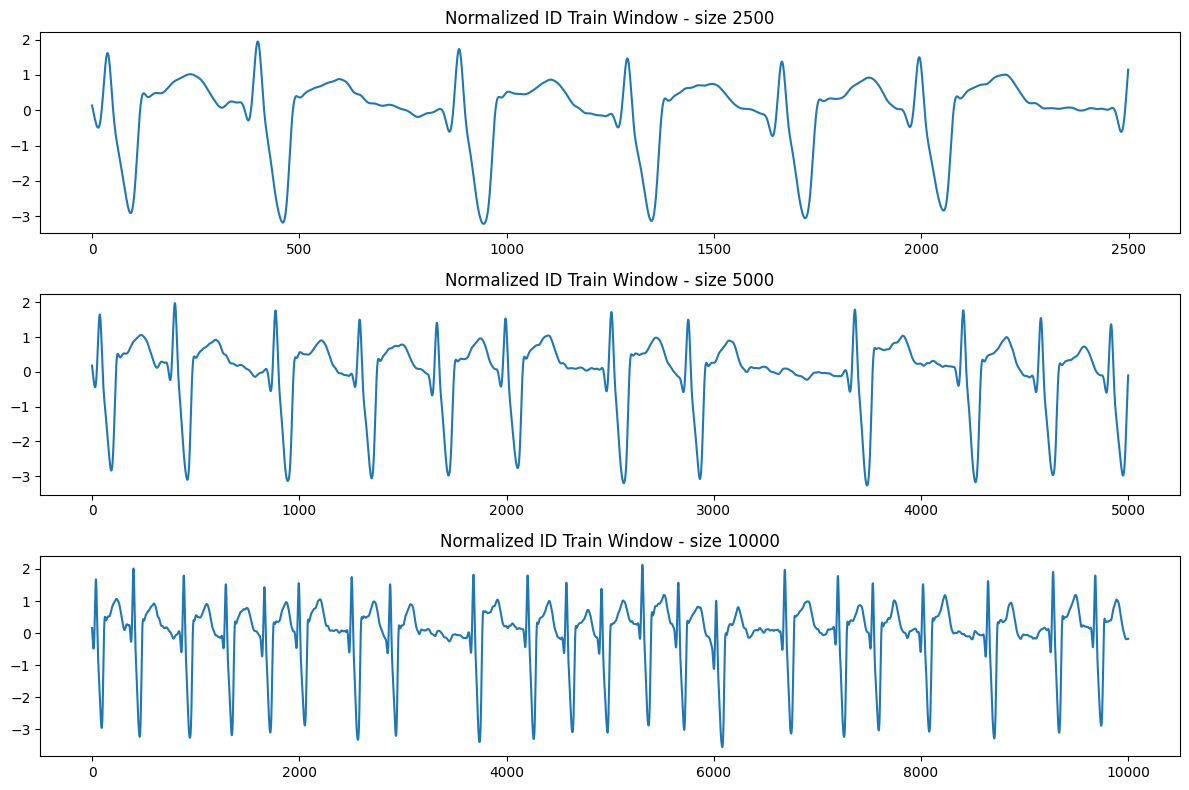

In [109]:
#Normalized window example
fig, axes = plt.subplots(len(WINDOW_SIZES), 1, figsize=(12, 8))

for i, window_size in enumerate(WINDOW_SIZES):
    example = final_arrays_by_size[window_size]["id_train"][0]
    axes[i].plot(example[:, 0])
    axes[i].set_title(f"Normalized ID Train Window - size {window_size}")

plt.tight_layout()
plt.show()

## 11) Save Prepared Data

In [110]:
# Save arrays and metadata
for window_size in WINDOW_SIZES:
    save_dir = WINDOWED_DATA_DIR / f"window_{window_size}"
    save_dir.mkdir(parents=True, exist_ok=True)  # Create the directory if it doesn't exist
    print(f"\nSaving window size {window_size} to {save_dir}")

    # Arrays
    np.save(save_dir / "X_id_train.npy", final_arrays_by_size[window_size]["id_train"])
    np.save(save_dir / "X_id_val.npy",   final_arrays_by_size[window_size]["id_val"])
    np.save(save_dir / "X_id_test.npy",  final_arrays_by_size[window_size]["id_test"])
    np.save(save_dir / "X_ood_test.npy", final_arrays_by_size[window_size]["ood_test"])

    # Metadata (using helper function)
    save_metadata(final_metadata_by_size[window_size]["id_train"], f"id_train_window_{window_size}_metadata")
    save_metadata(final_metadata_by_size[window_size]["id_val"],   f"id_val_window_{window_size}_metadata")
    save_metadata(final_metadata_by_size[window_size]["id_test"],  f"id_test_window_{window_size}_metadata")
    save_metadata(final_metadata_by_size[window_size]["ood_test"], f"ood_test_window_{window_size}_metadata")

    print("Saved arrays:")
    print("  X_id_train:", final_arrays_by_size[window_size]["id_train"].shape)
    print("  X_id_val:  ", final_arrays_by_size[window_size]["id_val"].shape)
    print("  X_id_test: ", final_arrays_by_size[window_size]["id_test"].shape)
    print("  X_ood_test:", final_arrays_by_size[window_size]["ood_test"].shape)


Saving window size 2500 to /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/windowed/window_2500
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_train_window_2500_metadata.csv  (116315 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_val_window_2500_metadata.csv  (25081 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/id_test_window_2500_metadata.csv  (25139 rows)
Saved metadata: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/metadata/ood_test_window_2500_metadata.csv  (75852 rows)
Saved arrays:
  X_id_train: (116315, 2500, 1)
  X_id_val:   (25081, 2500, 1)
  X_id_test:  (25139, 2500, 1)
  X_ood_test: (75852, 2500, 1)

Saving window size 5000 to /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/windowed/window_5000
Saved metadata: /content/drive/My D

In [111]:
#Save preprocessing config
processing_summary = {
    "sampling_rate": SAMPLING_RATE,
    "window_sizes": WINDOW_SIZES,
    "stride_ratio": WINDOW_STRIDE_RATIO,
    "lowcut": LOWCUT,
    "highcut": HIGHCUT,
    "notch_freq": NOTCH_FREQ,
    "filter_order": FILTER_ORDER,
    "quality_factor": QUALITY_FACTOR,
    "normalization_method": NORMALIZATION_METHOD,
    "epsilon": EPSILON,
    "min_signal_length": MIN_SIGNAL_LENGTH,
    "max_nan_ratio": MAX_NAN_RATIO,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "random_seed": RANDOM_SEED,
}

with open(WINDOWED_DATA_DIR / "processing_summary.json", "w") as f:
    json.dump(processing_summary, f, indent=4)

print("Saved processing summary:", WINDOWED_DATA_DIR / "processing_summary.json")

Saved processing summary: /content/drive/My Drive/Duke/Semester 4/singlelead_ecgad/data_singlelead/windowed/processing_summary.json


## 13) Visualizations

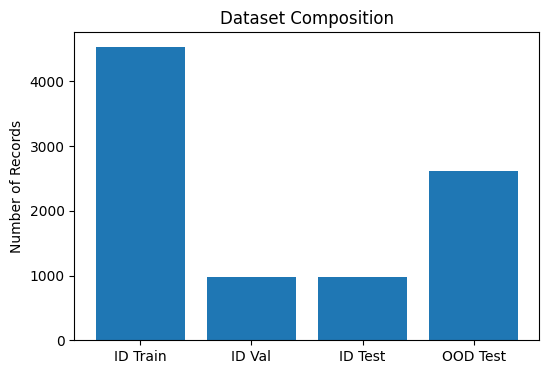

In [112]:
#Dataset Composition (ID vs. OOD)
counts = [
    len(id_train_records),
    len(id_val_records),
    len(id_test_records),
    len(ood_test_records)
]

labels = ["ID Train", "ID Val", "ID Test", "OOD Test"]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)

plt.title("Dataset Composition")
plt.ylabel("Number of Records")

plt.show()

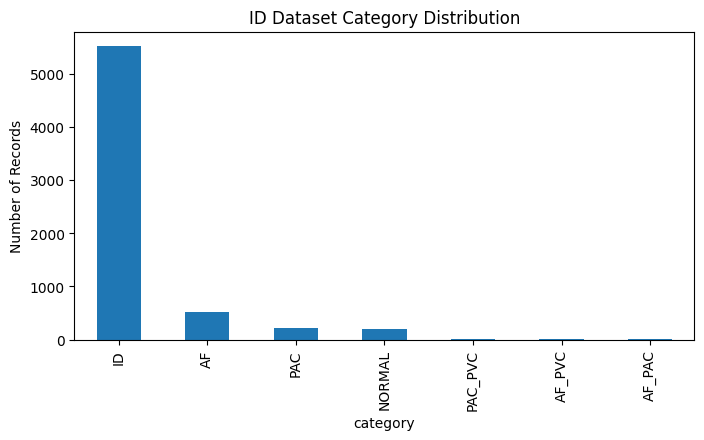

In [113]:
#ID category distribution
plt.figure(figsize=(8,4))

id_metadata["category"].value_counts().plot(kind="bar")

plt.title("ID Dataset Category Distribution")
plt.ylabel("Number of Records")

plt.show()

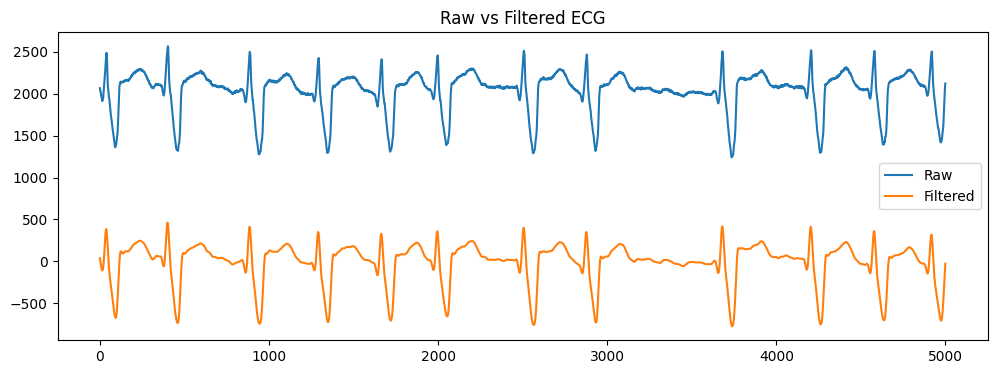

In [114]:
#Raw vs. Filtered ECG (Pipeline Visualization)
raw_example = id_records[0]["ecg"].squeeze()
clean_example = id_standardized_records[0]["ecg"].squeeze()

plt.figure(figsize=(12,4))

plt.plot(raw_example[:5000], label="Raw")
plt.plot(clean_example[:5000], label="Filtered")

plt.title("Raw vs Filtered ECG")
plt.legend()

plt.show()

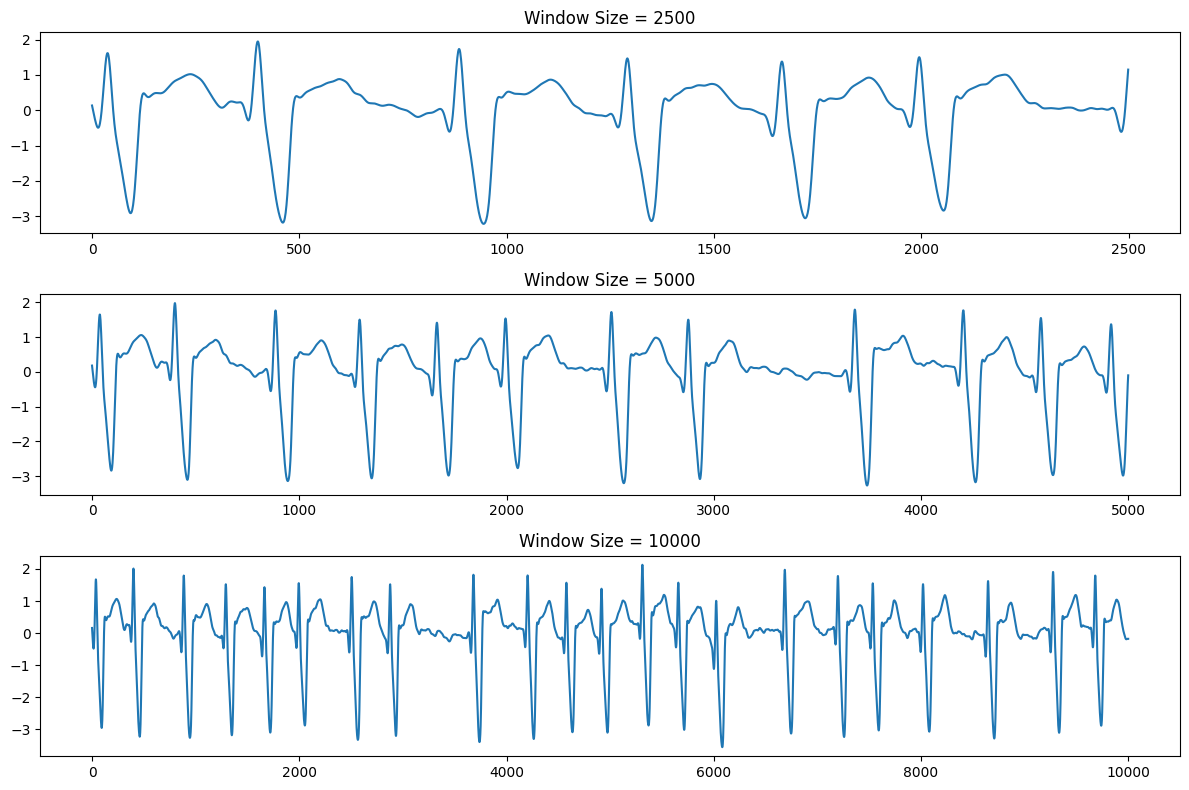

In [115]:
#Window size comparison
fig, axes = plt.subplots(len(WINDOW_SIZES), 1, figsize=(12,8))

for i, window_size in enumerate(WINDOW_SIZES):

    example = final_arrays_by_size[window_size]["id_train"][0]

    axes[i].plot(example[:,0])
    axes[i].set_title(f"Window Size = {window_size}")

plt.tight_layout()
plt.show()

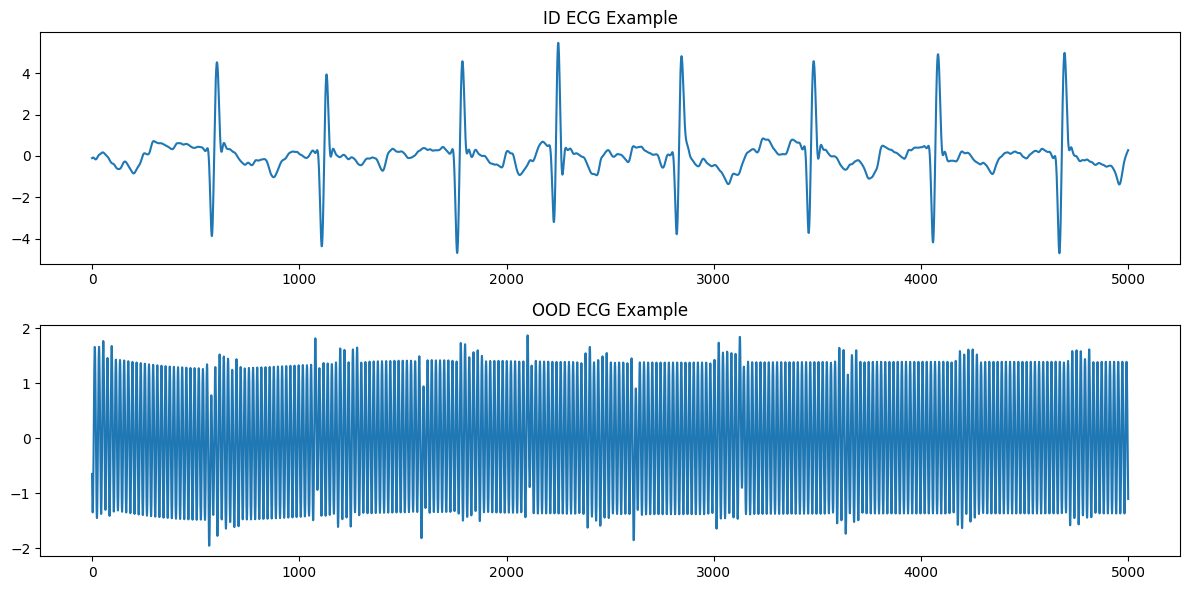

In [117]:
#ID vs. OOD
fig, axes = plt.subplots(2,1, figsize=(12,6))

id_example = final_arrays_by_size[5000]["id_test"][0]
ood_example = final_arrays_by_size[5000]["ood_test"][1]

axes[0].plot(id_example[:,0])
axes[0].set_title("ID ECG Example")

axes[1].plot(ood_example[:,0])
axes[1].set_title("OOD ECG Example")

plt.tight_layout()
plt.show()

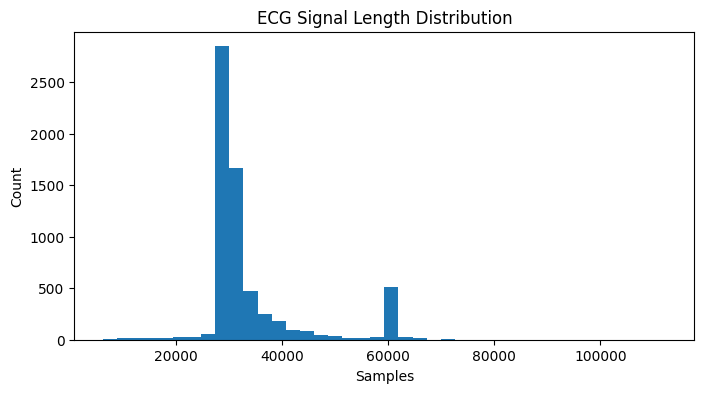

In [118]:
#Signal Length Distribution
lengths = [len(r["ecg"]) for r in id_records]

plt.figure(figsize=(8,4))

plt.hist(lengths, bins=40)

plt.title("ECG Signal Length Distribution")
plt.xlabel("Samples")
plt.ylabel("Count")

plt.show()